In [1]:
!pip install -q bitsandbytes>0.46.1

In [2]:
# Profile a float model fp16

#Profile a quantized model (bits and byttes int8)


In [3]:
import json
import argparse
import math
import pathlib as Path
from collections import defaultdict
from dataclasses import dataclass, asdict, field
from typing import Optional

import torch
import torch.nn as nn
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import bitsandbytes
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

In [4]:
#Config

DEFAULT_MODEL = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
DEFAULT_N_SAMPLES   = 64        # calibration samples to run forward passes on
DEFAULT_MAX_TOKENS  = 256       # truncate inputs to this length
OUTLIER_SIGMA       = 3.0       # values beyond N std-devs are "outliers"

# Layer types we care about — all linear projections in a transformer
TARGET_MODULE_TYPES = (nn.Linear)

In [5]:
# data structures

@dataclass
class TensorStats:
    """Descriptive statistics for a single tensor (weights or activations)."""
    min:          float = 0.0
    max:          float = 0.0
    mean:         float = 0.0
    std:          float = 0.0
    kurtosis:     float = 0.0   # >3 = heavy-tailed; INT quantization struggles here
    outlier_pct:  float = 0.0   # % of values beyond OUTLIER_SIGMA std-devs from mean
    abs_max:      float = 0.0   # useful for determining quantization range
    dynamic_range: float = 0.0  # abs_max / (std + eps) — how "spiky" the distribution is

@dataclass
class LayerStats:
    """All statistics for one named linear layer."""
    name:        str
    shape:       list[int]              # weight shape [out, in]
    weight:      TensorStats = field(default_factory=TensorStats)
    activation:  TensorStats = field(default_factory=TensorStats)  # averaged across samples
    # Running accumulators (not serialised) — used during hook collection
    _act_buffer: list = field(default_factory=list, repr=False)



In [6]:
# Statistics helpers
# ---------------------------------------------------------------------------

def _compute_stats(t: torch.Tensor) -> TensorStats:
    """
    Compute descriptive stats on a flattened float32 tensor.
    Safe against zero-variance tensors.
    """
    t = t.detach().float().flatten()

    mn   = t.min().item()
    mx   = t.max().item()
    mean = t.mean().item()
    std  = t.std().item()
    eps  = 1e-8

    # Kurtosis: E[(x-mu)^4] / sigma^4  (excess kurtosis = this - 3)
    # High kurtosis → heavy tails → large outlier values relative to spread
    centered = t - mean
    kurtosis = (centered.pow(4).mean() / (std ** 4 + eps)).item()

    # Outlier fraction: values more than OUTLIER_SIGMA std-devs from mean
    outlier_mask = centered.abs() > (OUTLIER_SIGMA * std)
    outlier_pct  = (outlier_mask.float().mean() * 100).item()

    abs_max       = t.abs().max().item()
    dynamic_range = abs_max / (std + eps)

    return TensorStats(
        min=mn, max=mx, mean=mean, std=std,
        kurtosis=kurtosis, outlier_pct=outlier_pct,
        abs_max=abs_max, dynamic_range=dynamic_range,
    )


def _average_stats(stats_list: list[TensorStats]) -> TensorStats:
    """Average a list of TensorStats (used to aggregate activation stats across samples)."""
    if not stats_list:
        return TensorStats()
    fields = TensorStats.__dataclass_fields__.keys()
    averaged = {}
    for f in fields:
        averaged[f] = sum(getattr(s, f) for s in stats_list) / len(stats_list)
    return TensorStats(**averaged)


In [7]:
# Hook registration
# ---------------------------------------------------------------------------

class LayerProfiler:
    """
    Attaches forward hooks to all TARGET_MODULE_TYPES in a model.
    After running forward passes, call .collect() to get LayerStats per layer.

    How hooks work:
        register_forward_hook(fn) calls fn(module, input, output) after
        every forward pass through that module. We use this to capture
        the *input activations* seen by each linear layer in production.
        Weight stats are read directly from module.weight — no hook needed.
    """

    def __init__(self, model: nn.Module):
        self.model   = model
        self._stats: dict[str, LayerStats]  = {}
        self._hooks:  list[torch.utils.hooks.RemovableHook] = []
        self._register_hooks()

    def _register_hooks(self):
        for name, module in self.model.named_modules():
            if isinstance(module, TARGET_MODULE_TYPES):
                # Capture name in closure — Python loop variable would be reused
                layer_name = name
                self._stats[layer_name] = LayerStats(
                    name=layer_name,
                    shape=list(module.weight.shape),
                )
                hook = module.register_forward_hook(
                    self._make_hook(layer_name)
                )
                self._hooks.append(hook)

        print(f"  Registered hooks on {len(self._stats)} linear layers")

    def _make_hook(self, name: str):
        """
        Returns a closure capturing `name`.

        hook(module, input, output):
          - input is a tuple; input[0] is the activation tensor entering the layer
          - We store stats for this one forward pass in _act_buffer
        """
        def hook(module: nn.Module,
                 inp: tuple[torch.Tensor, ...],
                 out: torch.Tensor):
            activation = inp[0]  # shape: [batch, seq_len, hidden_dim]
            stats = _compute_stats(activation)
            self._stats[name]._act_buffer.append(stats)
        return hook

    def remove_hooks(self):
        """Always call this after profiling — hooks hold references and cause memory leaks."""
        for h in self._hooks:
            h.remove()
        self._hooks.clear()

    def collect(self) -> dict[str, LayerStats]:
        """
        Finalise stats: compute weight stats and average buffered activation stats.
        Returns dict of layer_name → LayerStats.
        """
        for name, module in self.model.named_modules():
            if name not in self._stats:
                continue
            ls = self._stats[name]

            # Weight stats — read directly, no hook needed
            ls.weight = _compute_stats(module.weight)

            # Activation stats — average over all forward passes
            ls.activation = _average_stats(ls._act_buffer)
            ls._act_buffer.clear()

        return self._stats

In [8]:
# Calibration data loader
# ---------------------------------------------------------------------------

def load_calibration_inputs(
    tokenizer,
    n_samples:  int = DEFAULT_N_SAMPLES,
    max_tokens: int = DEFAULT_MAX_TOKENS,
    calib_jsonl: Optional[str] = None,
) -> list[torch.Tensor]:
    """
    Returns a list of input_id tensors ready for model forward passes.

    If calib_jsonl is provided (output of build_calib_dataset.py), loads from there.
    Otherwise falls back to WikiText-2 so the profiler works standalone.
    """
    texts = []

    if calib_jsonl:
        print(f"  Loading calibration samples from {calib_jsonl}")
        with open(calib_jsonl) as f:
            for line in f:
                row = json.loads(line)
                texts.append(row["prompt"] + " " + row["response"])
                if len(texts) >= n_samples:
                    break
    else:
        print("  No calib JSONL provided — falling back to WikiText-2")
        ds = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")
        for row in ds:
            if row["text"].strip():
                texts.append(row["text"].strip())
            if len(texts) >= n_samples:
                break

    # Tokenise and truncate
    input_tensors = []
    for text in texts[:n_samples]:
        ids = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            max_length=max_tokens,
        ).input_ids
        input_tensors.append(ids)

    print(f"  Loaded {len(input_tensors)} calibration inputs")
    return input_tensors


In [9]:
# Main profiling routine
# ---------------------------------------------------------------------------

def profile_model(
    model_name:  str,
    output_path: Optional[str]  = None,
    quantize:    Optional[str]  = None,
    n_samples:   int            = DEFAULT_N_SAMPLES,
    max_tokens:  int            = DEFAULT_MAX_TOKENS,
    calib_jsonl: Optional[str]  = None,
    device:      str            = "auto",
) -> dict:
    """
    Load model, run calibration inputs through it with hooks active,
    collect per-layer stats, and return as a dict.

    output_path : path to save JSON, or None to skip saving (Colab default).
    """

    # --- 1. Load model ---
    print(f"\nLoading model: {model_name}  (quantize={quantize})")
    load_kwargs = dict(device_map=device, torch_dtype=torch.float16)

    if quantize == "int8":
        load_kwargs["quantization_config"] = BitsAndBytesConfig(load_in_8bit=True)
    elif quantize == "int4":
        load_kwargs["quantization_config"] = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=torch.float16,
        )

    model     = AutoModelForCausalLM.from_pretrained(model_name, **load_kwargs)
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model.eval()
    print(f"  Parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")

    # --- 2. Attach hooks ---
    print("\nAttaching hooks ...")
    profiler = LayerProfiler(model)

    # --- 3. Load calibration data ---
    print("\nLoading calibration data ...")
    inputs = load_calibration_inputs(tokenizer, n_samples, max_tokens, calib_jsonl)

    # --- 4. Run forward passes ---
    print(f"\nRunning {len(inputs)} forward passes ...")
    with torch.no_grad():
        for i, input_ids in enumerate(inputs):
            if i % 10 == 0:
                print(f"  [{i+1}/{len(inputs)}]")
            try:
                input_ids = input_ids.to(model.device)
                model(input_ids)
            except Exception as e:
                print(f"  WARNING: forward pass {i} failed: {e}")
                continue

    # --- 5. Collect and serialise ---
    print("\nCollecting stats ...")
    profiler.remove_hooks()
    stats = profiler.collect()

    # Convert to JSON-serialisable dict
    output = {
        "meta": {
            "model":      model_name,
            "quantize":   quantize,
            "n_samples":  n_samples,
            "max_tokens": max_tokens,
            "n_layers":   len(stats),
        },
        "layers": {
            name: {
                "shape":      ls.shape,
                "weight":     asdict(ls.weight),
                "activation": asdict(ls.activation),
            }
            for name, ls in stats.items()
        }
    }

    if output_path is not None:
        import pathlib
        out = pathlib.Path(output_path)
        out.parent.mkdir(parents=True, exist_ok=True)
        with out.open("w") as f:
            json.dump(output, f, indent=2)
        print(f"\nSaved → {out.resolve()}")

    print(f"\nDone. {len(stats)} layers profiled.")
    return output



In [14]:
# Summary + diff helpers
# ---------------------------------------------------------------------------

def _to_dataframe(data: dict):
    """
    Convert the stats dict returned by profile_model() into a flat pandas DataFrame.
    Each row is one layer; columns cover both weight and activation stats.
    """
    import pandas as pd
    rows = []
    for name, ls in data["layers"].items():
        w = ls["weight"]
        a = ls["activation"]
        rows.append({
            "layer":             name,
            "shape":             str(ls["shape"]),
            "act_outlier_pct":   round(a["outlier_pct"],   3),
            "act_kurtosis":      round(a["kurtosis"],       3),
            "act_dynamic_range": round(a["dynamic_range"],  3),
            "act_abs_max":       round(a["abs_max"],        4),
            "act_std":           round(a["std"],            4),
            "w_outlier_pct":     round(w["outlier_pct"],   3),
            "w_kurtosis":        round(w["kurtosis"],       3),
            "w_dynamic_range":   round(w["dynamic_range"],  3),
        })
    df = pd.DataFrame(rows).set_index("layer")
    return df


def show_summary(data, top_n=15, sort_by="act_outlier_pct"):
    rows = []
    for name, ls in data["layers"].items():
        a = ls["activation"]
        w = ls["weight"]
        rows.append({
            "layer":             name.replace("model.layers.", "L").replace(".self_attn", ".attn").replace(".mlp", ".mlp"),
            "act_outlier_pct":     round(a["outlier_pct"],   2),
            "act_kurtosis":      round(a["kurtosis"],       2),
            "act_dyn_range":     round(a["dynamic_range"],  2),
            "act_abs_max":       round(a["abs_max"],        4),
            "w_outlier_%":       round(w["outlier_pct"],   2),
            "w_kurtosis":        round(w["kurtosis"],       2),
        })

    df = pd.DataFrame(rows).set_index("layer")
    top = df.sort_values(sort_by, ascending=False).head(top_n)

    cols        = list(top.columns)
    values      = top.values.astype(float)
    n_rows, n_cols = values.shape

    # Normalise each column independently 0→1 for coloring
    col_min  = values.min(axis=0)
    col_max  = values.max(axis=0)
    col_range = np.where(col_max - col_min == 0, 1, col_max - col_min)
    normed   = (values - col_min) / col_range   # shape [n_rows, n_cols]

    fig, ax = plt.subplots(figsize=(max(10, n_cols * 1.6), max(5, n_rows * 0.52)))

    im = ax.imshow(normed, cmap="YlOrRd", aspect="auto", vmin=0, vmax=1)

    # Annotate each cell with its actual value
    for r in range(n_rows):
        for c in range(n_cols):
            brightness = normed[r, c]
            txt_color  = "white" if brightness > 0.6 else "black"
            ax.text(c, r, f"{values[r, c]:.2f}",
                    ha="center", va="center",
                    fontsize=8.5, color=txt_color, fontweight="normal")

    # Axes labels
    ax.set_xticks(range(n_cols))
    ax.set_xticklabels(cols, rotation=30, ha="right", fontsize=9)
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels(top.index, fontsize=8.5)
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position("top")

    # Colourbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.01)
    cbar.set_label("relative intensity (per column)", fontsize=8)
    cbar.set_ticks([0, 0.5, 1])
    cbar.set_ticklabels(["low", "mid", "high"])

    quant_label = data["meta"]["quantize"] or "float"
    ax.set_title(
        f"Layer sensitivity heatmap  |  {data['meta']['model'].split('/')[-1]}  "
        f"|  {quant_label}  |  top {top_n} by {sort_by}",
        fontsize=10, pad=18, loc="left"
    )

    plt.tight_layout()
    plt.show()
    return df

def show_diff(data_a, data_b, label_a="float", label_b="quant", top_n=15):
    cols = ["act_outlier_pct", "act_kurtosis", "act_dynamic_range", "w_outlier_pct"]
    def to_df(data):
        rows = []
        for name, ls in data["layers"].items():
            a, w = ls["activation"], ls["weight"]
            rows.append({"layer": name,
                "act_outlier_pct":   a["outlier_pct"],
                "act_kurtosis":      a["kurtosis"],
                "act_dynamic_range": a["dynamic_range"],
                "w_outlier_pct":     w["outlier_pct"],
            })
        return pd.DataFrame(rows).set_index("layer")

    df_a, df_b = to_df(data_a), to_df(data_b)
    common = df_a.index.intersection(df_b.index)
    delta  = (df_b.loc[common, cols] - df_a.loc[common, cols]).round(3)
    delta.columns = [f"d_{c}" for c in cols]
    delta["degraded"] = delta["d_act_outlier_pct"] > 2.0
    delta = delta.sort_values("d_act_outlier_pct", ascending=False, key=abs)
    print(f"\ndiff: {label_a} → {label_b}  |  top {top_n} by |d_act_outlier_pct|\n")
    print(delta.head(top_n).to_string())
    return delta # return full delta df for further analysis


In [15]:
# Entrypoint
# ---------------------------------------------------------------------------
if __name__ == "__main__":
  pass



Loading model: TinyLlama/TinyLlama-1.1B-Chat-v1.0  (quantize=None)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  Parameters: 1100.0M

Attaching hooks ...
  Registered hooks on 155 linear layers

Loading calibration data ...
  No calib JSONL provided — falling back to WikiText-2
  Loaded 32 calibration inputs

Running 32 forward passes ...
  [1/32]
  [11/32]
  [21/32]
  [31/32]


Done. 155 layers profiled.


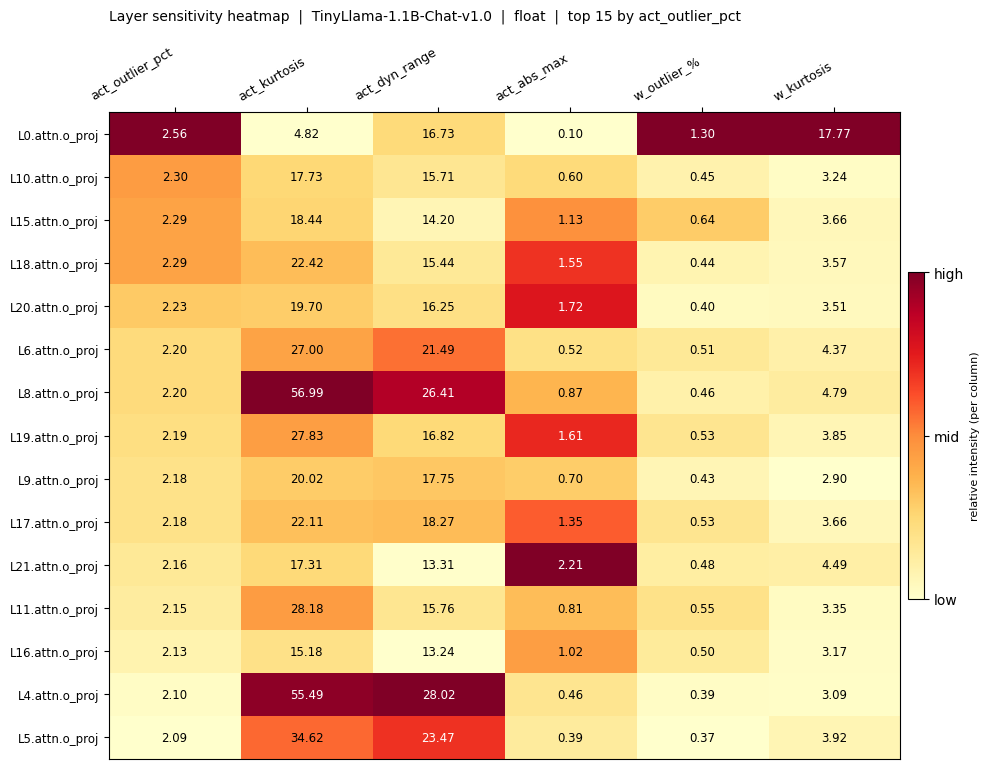

In [19]:
stats_float = profile_model(
    model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    n_samples  = 32,
)
df = show_summary(stats_float)


Loading model: TinyLlama/TinyLlama-1.1B-Chat-v1.0  (quantize=int4)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  Parameters: 615.6M

Attaching hooks ...
  Registered hooks on 155 linear layers

Loading calibration data ...
  No calib JSONL provided — falling back to WikiText-2
  Loaded 32 calibration inputs

Running 32 forward passes ...
  [1/32]
  [11/32]
  [21/32]
  [31/32]


Done. 155 layers profiled.


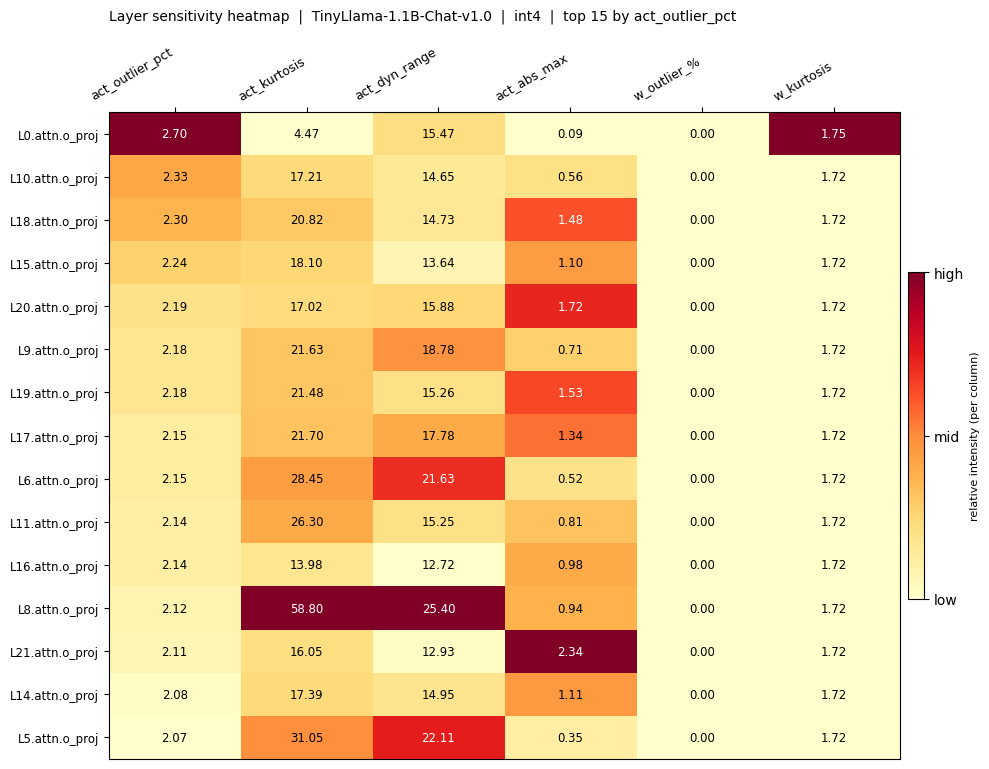

In [17]:
stats_int8 = profile_model(
    model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    quantize   = "int4",
    n_samples  = 32,
)
delta = show_summary(stats_int8)


In [ ]:
delta = show_diff(stats_float, stats_int8, label_a="float", label_b="int8")
